# In this class...

- ``Percentiles and Quantiles`` (with ``.quantile()``, ``.describe()`` and ``.plot(kind='box')``)



In [2]:
%matplotlib inline

In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import statistics
from scipy.stats import norm

from pathlib import Path
print('Imported libraries')

Imported libraries


In [4]:
actual_dir = Path.cwd()
data_dir = actual_dir.parent / 'data'

medals=pd.read_csv(data_dir/'medals.csv')

In [5]:
medals.keys()


Index(['Country', 'Gold Medal', 'Silver Medal', 'Bronze Medal', 'Total',
       'Rank By Total'],
      dtype='str')

In [6]:
total = medals['Total']

total_mean = total.mean()
total_var = total.var(ddof=0) # We do NOT apply Bessel's correction!
total_std = total.std(ddof=0) # Idem

In [7]:
# Ways to print the result:

# Old way:
message = "mean: {:.2f}, variance: {:.2f} and standard deviation: {:.2f} of medals in Olympic Games"
print(message.format(total_mean, total_var, total_std))


# "New" way:

print(
    f"mean: {total_mean:.2f}, "
    f"variance: {total_var:.2f} "
    f"and standard deviation: {total_std:.2f} of medals in Olympic Games"
)

mean: 11.61, variance: 360.56 and standard deviation: 18.99 of medals in Olympic Games
mean: 11.61, variance: 360.56 and standard deviation: 18.99 of medals in Olympic Games


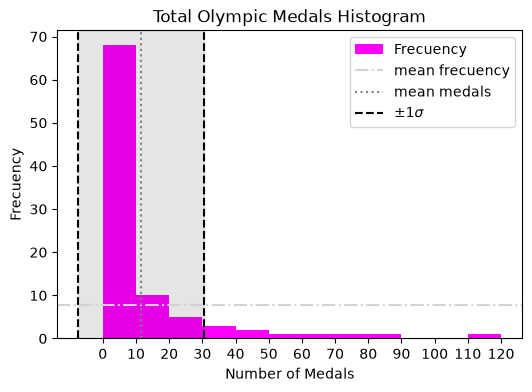

In [8]:
interval = range(min(total)-1, max(total)+10, 10) # Added +5 for making sure that there is enough space for the last bin (with the other 5, I make intervals of widht 5)

fig, ax = plt.subplots(figsize=(6, 4))

n, _, __ = ax.hist(total, bins= interval, color = 'magenta', rwidth=1, label='Frecuency') # rwidth = 1 so bars touch each other

freq_mean = n.mean()
ax.axhline(freq_mean, ls='-.', color='lightgrey', label='mean frecuency')

ax.axvline(x=total_mean, ls=':', color='gray', label='mean medals')
ax.axvline(total_mean - total_std, ls='--', color='black', label=r'$\pm 1 \sigma$')
ax.axvline(total_mean + total_std, ls='--', color='black')
ax.axvspan(total_mean - total_std, total_mean + total_std,
           color='black', alpha=0.1)


ax.set_title("Total Olympic Medals Histogram")
ax.set_xlabel("Number of Medals")
ax.set_ylabel("Frecuency")
ax.legend(loc='best')
plt.xticks(interval); 

## Percentiles and Quantiles


In [9]:
q1, q2, q3 = total.quantile([0.25, 0.5, 0.75])

interquantile = q3 - q1

q85 = total.quantile(0.85)

print(f"85% of the countries have {int(q85)} or less medals")


85% of the countries have 20 or less medals


In [10]:
total.describe()

count     93.000000
mean      11.612903
std       19.091332
min        1.000000
25%        2.000000
50%        4.000000
75%       11.000000
max      113.000000
Name: Total, dtype: float64

### Boxplots

In [11]:
gold = medals['Gold Medal']

Text(0.02, 0.95, 'Box = Q1–Q3\nLine = median\nDots = outliers')

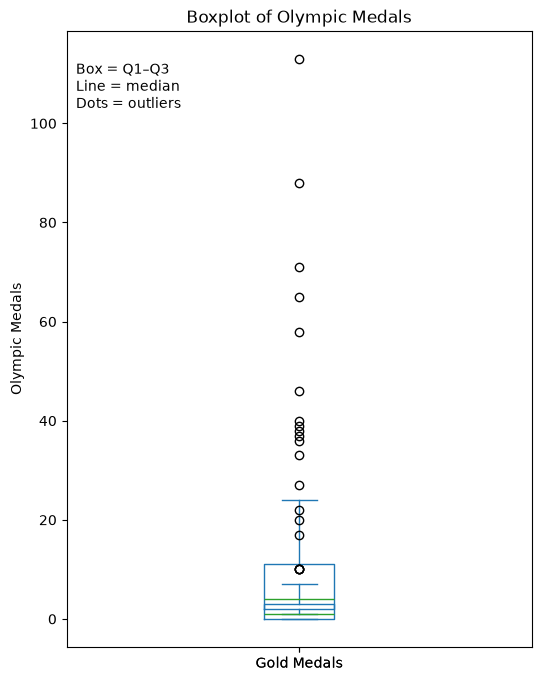

In [12]:
# How NOT to do it (overlapping of the two boxes):

fig, ax = plt.subplots(figsize=(6,8))

total.plot(kind="box", ax=ax, vert=True)
gold.plot(kind="box", ax=ax, vert=True)

ax.set_title("Boxplot of Olympic Medals")
ax.set_ylabel("Olympic Medals")
ax.set_xticklabels(["Total Medals", "Gold Medals"])


ax.text(
    0.02, 0.95,
    "Box = Q1–Q3\nLine = median\nDots = outliers",
    transform=ax.transAxes,
    va="top"
)

Text(0.7, 0.95, 'Box = Q1–Q3\nLine = median\nDots = outliers')

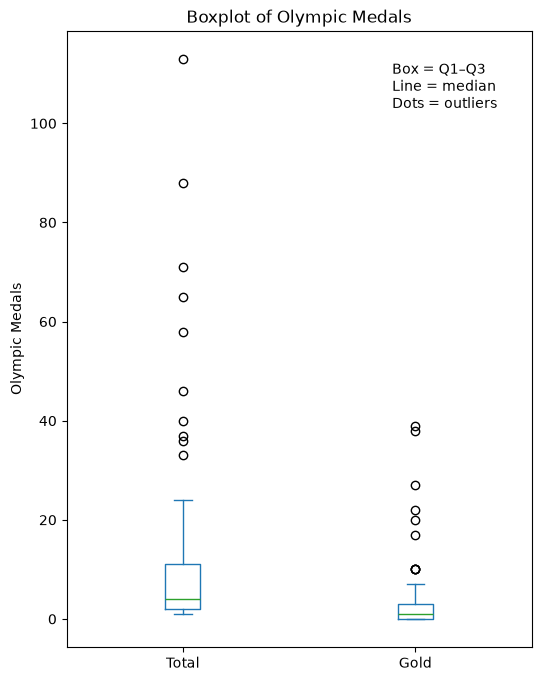

In [13]:
# How to do it (NO overlapping):

# First I create a new DataFrame with the data I want to "box"
df_box = pd.DataFrame(
    {"Total": total, 
     "Gold": gold}
)

fig, ax = plt.subplots(figsize=(6,8))

df_box.plot(kind="box", ax=ax, vert=True)

ax.set_title("Boxplot of Olympic Medals")
ax.set_ylabel("Olympic Medals")
# ax.set_xticklabels(["Total Medals", "Gold Medals"])


ax.text(
    0.7, 0.95,
    "Box = Q1–Q3\nLine = median\nDots = outliers",
    transform=ax.transAxes,
    va="top"
)

## Distributions

### Normal Distribution

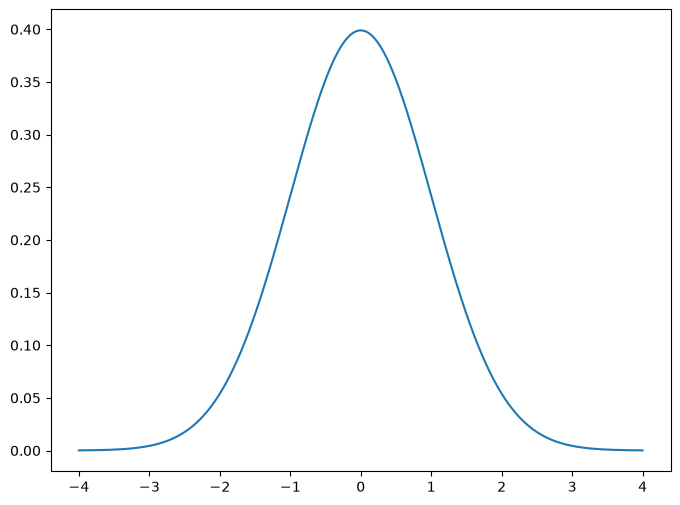

In [14]:
lim = 4
mean = 0
std = 1
x_norm = np.arange(-lim, lim, 0.001)
y_norm = norm.pdf(x_norm, mean, std)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(x_norm, y_norm)

In [15]:
# Let's try to obtain the mean and the standard deviation just from the data:

mean_calc = np.trapezoid(x_norm * y_norm, x_norm)
std_calc = np.sqrt(np.trapezoid((x_norm-mean_calc)**2 * y_norm, x_norm))


print(f"Mean: {mean_calc:.2f}, Standard Deviation: {std_calc:.2f}")

Mean: -0.00, Standard Deviation: 1.00


In [16]:
integral = np.trapezoid(y_norm, x_norm)
print(f"Area under the curve: {integral:.2f}")

Area under the curve: 1.00


In [17]:
notebook = Path.cwd().parent
files= notebook/'data'

demo = pd.read_csv(files/'demography.csv', sep=';')
demo

,Year,AC,Province,Judicial District,Population,Proportion of women,Proportion of foreigners,Dependency ratio,Population density,Degree of ageing,Live Births by maternal residence,Marriages,Deaths:,Natural growth,Under 16-year-olds male,Under 16-year-olds female,Total under 16-year-olds,Under 18-year-olds male,Under 18-year-olds female,Total under 18-year-olds
0,2025,Canarias,Santa Cruz de Tenerife,Santa Cruz de Tenerife,229526,"0,52177531085803","0,078792816500092","0,44928396433713","1209,6231640878","0,10317785348937",1074,777,2226,-1152,13309,12763,26072,15814,15031,30845
1,2025,Comunidad Foral de Navarra,Navarra,Tudela,103089,"0,49636721667685","0,18856522034359","0,54711629372833","93,111202810638","0,008806236232348",778,303,917,-139,8748,8070,16818,9998,9220,19218
2,2025,Comunidad de Madrid,Madrid,Alcalá de Henares,255146,"0,51297296449876","0,16577959286056","0,47251719839328","677,12109818576","0,016777916102225",1837,969,1649,188,19465,18179,37644,22670,21171,43841
3,2025,Galicia,A Coruña,Ordes,35087,"0,51021745945792","0,05492062587283","0,6498330747167","46,591331956967","0,040576688964981",175,123,454,-279,2157,2012,4169,2495,2292,4787
4,2025,Cataluña,Barcelona,Mollet del Vallès,109034,"0,50447566814021","0,11622979987894","0,47957065121518","2262,5856071794","0,028071191423907",600,420,864,-264,7833,7380,15213,9184,8656,17840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426,2025,Andalucía,Sevilla,Estepa,45878,"0,50034875103535","0,042416844675008","0,48534982355036","77,879441025726","0,018570992632634",347,168,403,-56,3552,3415,6967,4084,3956,8040
427,2025,Comunidad Valenciana,Alicante/Alacant,Alcoy,97941,"0,50342553169765","0,11786687903942","0,53871895178395","157,58048786771","0,0080846778016503",616,334,942,-326,6809,6360,13169,7933,7439,15372
428,2025,Andalucía,Granada,Almuñécar,30406,"0,50194040649872","0,20183516411235","0,5566477243639","170,3417348745","0,05935506150102",177,76,292,-115,2049,1899,3948,2384,2177,4561
429,2025,Comunidad Valenciana,Alicante/Alacant,Novelda,93407,"0,49651525046303","0,13297718586401","0,51374258581013","130,72326322341","0,020569122228527",660,335,765,-105,7071,6433,13504,8172,7516,15688


In [18]:
demo.keys()

Index(['Year', 'AC', 'Province', 'Judicial District', 'Population',
       'Proportion of women', 'Proportion of foreigners', 'Dependency ratio',
       'Population density', 'Degree of ageing',
       'Live Births by maternal residence', 'Marriages', 'Deaths:',
       'Natural growth', 'Under 16-year-olds male',
       'Under 16-year-olds female', 'Total under 16-year-olds',
       'Under 18-year-olds male', 'Under 18-year-olds female',
       'Total under 18-year-olds'],
      dtype='str')

<Axes: >

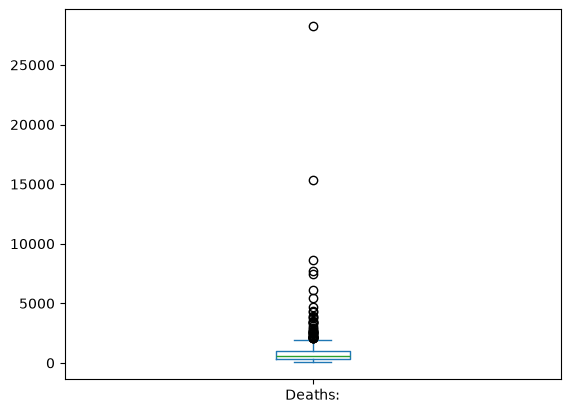

In [19]:
deaths = demo['Deaths:']

deaths.plot(kind='box')

In [35]:
# Hmmm, interesting, lets see what's the province with the highest number of deaths.

district = demo.loc[demo['Deaths:'].idxmax(),'Judicial District']

# or with our variables:

district_jorge = demo.loc[deaths.idxmax(),'Judicial District']

deaths_max=deaths.max()

print(district_jorge, deaths_max)

Madrid 28253


In [21]:
# All the info about the deathliest province:

demo.loc[deaths.idxmax()]

Year                                                2025
AC                                   Comunidad de Madrid
Province                                          Madrid
Judicial District                                 Madrid
Population                                       3477497
Proportion of women                     0,53094941562854
Proportion of foreigners                0,18846946525044
Dependency ratio                        0,47181436034956
Population density                       5740,6224934851
Degree of ageing                        0,20185610512389
Live Births by maternal residence                  26340
Marriages                                          15866
Deaths:                                            28253
Natural growth                                     -1913
Under 16-year-olds male                           227426
Under 16-year-olds female                         217449
Total under 16-year-olds                          444875
Under 18-year-olds male        

In [ ]:
# Albeit the most important parameter should be deaths/population:

demo['Deaths_per_person'] = deaths /demo['Population']

deaths_pax = demo['Deaths_per_person']

province_max_deaths_pax = demo.loc[deaths_pax.idxmax(), 'Judicial District']
max_deaths_pax= deaths_pax.max()

print(province_max_deaths_pax, max_deaths_pax)

Lugo 0.025801011804384485


In [37]:
demo[['Judicial District','Deaths_per_person']].sort_values(by='Deaths_per_person', ascending=False)

,Judicial District,Deaths_per_person
352,A Fonsagrada,0.025801
380,A Pobra de Trives,0.022907
388,Alcaraz,0.022677
24,Bande,0.022482
341,Villalpando,0.022131
...,...,...
89,Illescas,0.004830
187,Arganda del Rey,0.004723
152,Parla,0.004614
367,Puerto del Rosario,0.004555
